<a href="https://colab.research.google.com/github/EstevaoMO/machine-learning-aprendizadodemaquina/blob/main/01_fundamentos_de_ml/colabs/Explora%C3%A7%C3%A3o_Visual_e_a_Formula%C3%A7%C3%A3o_de_Hip%C3%B3teses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploração Visual e a Formulação de Hipóteses**

In [4]:
# %pip install pandas seaborn matplotlib

## **1. A Pergunta de Negócio**

### Análise Sem Objetivo é Perda de Tempo
Na metodologia de projetos de dados, a primeira etapa jamais é a codificação. É o **Entendimento do Negócio**. Abrir um dataset e começar a gerar gráficos aleatórios sem uma hipótese prévia é o equivalente a andar em círculos. Antes de o algoritmo procurar padrões, o cientista de dados precisa saber o que está procurando.

Para este módulo, utilizaremos dados reais de gorjetas deixadas em um restaurante. Nosso vetor-alvo ($y$) será a gorjeta (`tip`). Nossa matriz de features ($X$) conterá informações da mesa (`total_bill`, `sex`, `smoker`, `day`, `time`, `size`).


> *Antes de rodar a célula abaixo e ver os dados, qual é a sua aposta lógica? Se uma mesa gasta o dobro do valor na refeição, a gorjeta sempre dobra proporcionalmente? Ou será que o contexto (como ser fumante ou o horário do dia) muda essa regra? Formule mentalmente sua hipótese.*

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando o dataset e observando o contexto do negócio
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## **2. Dispersão Bivariada e a Tendência Linear Intuitiva**

### A Relação Entre Duas Variáveis

A forma mais pura de investigar a relação entre uma variável explicativa contínua ($X$: `total_bill`) e nossa variável-alvo ($y$: `tip`) é através de um gráfico de dispersão (*scatterplot*).

Aqui, pediremos para a biblioteca traçar uma **linha de tendência**. Essa reta é exatamente o que um modelo simples de Regressão Linear tentaria aprender: o caminho matemático que melhor cruza a nuvem de pontos minimizando os erros.


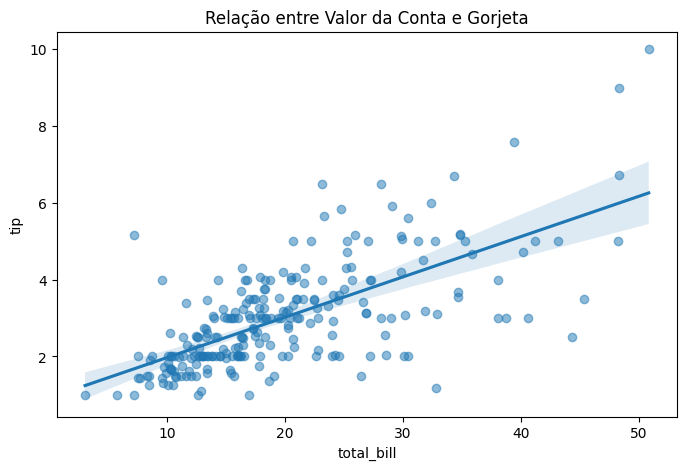

In [6]:
# Mapeando X (Conta) vs y (Gorjeta) com uma linha de tendência (Regressão)
plt.figure(figsize=(8, 5))
sns.regplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha':0.5})
plt.title("Relação entre Valor da Conta e Gorjeta")
plt.show()

> *Olhe para a nuvem de pontos. Existe uma tendência clara de subida: contas maiores geram gorjetas maiores. Se um cliente gastar \$50, a linha central nos faz esperar algo em torno de \$5 a \$6 de gorjeta. Mas note os pontos ao redor da reta: **por que a dispersão (a incerteza) aumenta conforme a conta fica mais cara?** Contas baratas têm gorjetas muito previsíveis, mas mesas que gastam muito tornam-se imprevisíveis.*


## 3. Adicionando Dimensões (Segmentação por Cores)

### Do 2D para o 3D Visual

O mundo real raramente é explicado por apenas uma variável. O modelo de Machine Learning trabalhará com um hiperplano multidimensional (várias colunas ao mesmo tempo). Visualmente, não conseguimos enxergar em 4 ou 5 dimensões, mas podemos usar **cores** para adicionar novas variáveis categóricas à nossa análise plana.

Vamos adicionar a variável `time` (Almoço vs. Janta) para ver se o comportamento muda.
**Tente formular uma hipótese antes de olhar o gráfico. Depois, verifique se sua hipótese foi compatível**

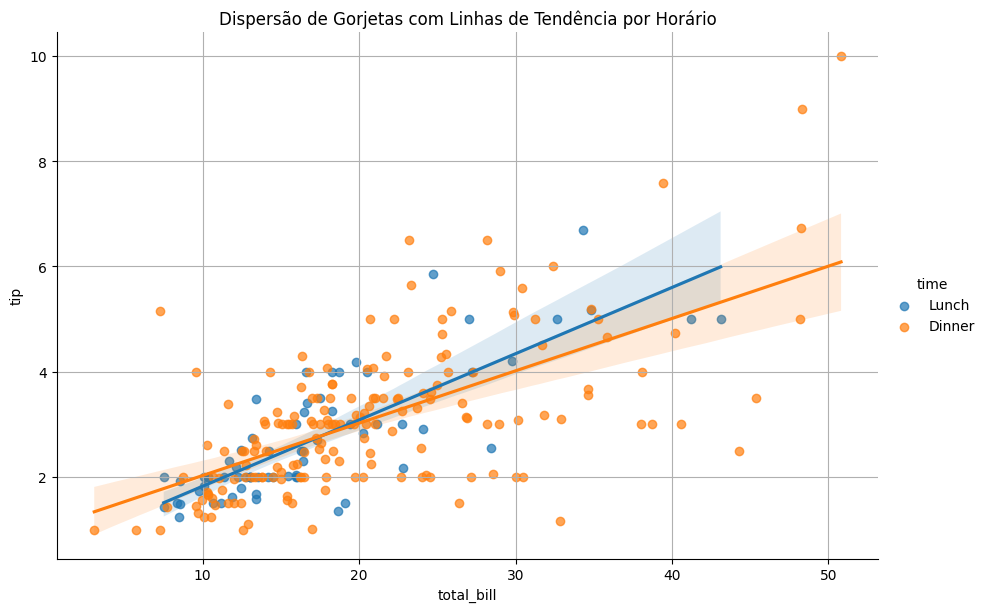

In [14]:
# Adicionando uma terceira dimensão visual através do parâmetro 'hue' (cor) e linhas de tendência

sns.lmplot(data=tips, x='total_bill', y='tip', hue='time', height=6, aspect=1.5, scatter_kws={'alpha':0.7})
plt.title("Dispersão de Gorjetas com Linhas de Tendência por Horário")
plt.grid(True)
plt.show()

> *Quais as percepções que você consegue alcançar sobre como os horários afetam as gorjetas?*

> *Suas hipóteses coincidiram com o observado? O interessante é que, mesmo que não, elas podem não estar erradas. Tudo depende do contexto, do domínio do problema. Neste contexto, a história pode ter sido outra. Maturidade na análise de dados é saber quando descartar suas hipóteses ao observar o contrário.*

## 4. Identificação Visual de Anomalias (Outliers)

### O Impacto do Ponto Fora da Curva

Algoritmos de aprendizado baseados em distância ou variância (como a Regressão Linear) são extremamente sensíveis a anomalias. Um único ponto muito fora do padrão pode "puxar" a linha de tendência matemática na direção errada, piorando a generalização do modelo.

> *Olhe novamente para os gráficos acima. Encontre os pontos extremos no canto superior esquerdo (contas baixas com gorjetas desproporcionalmente altas) ou no canto inferior direito (contas de $ 50 que deixaram quase nada de gorjeta).*
> *O que pode explicar isso? Um erro de digitação do garçom no sistema? Um cliente que foi extremamente mal atendido? Esses pontos refletem o comportamento padrão que queremos que a máquina aprenda ou são exceções (ruídos) que vão confundir a matemática do nosso algoritmo no futuro?*

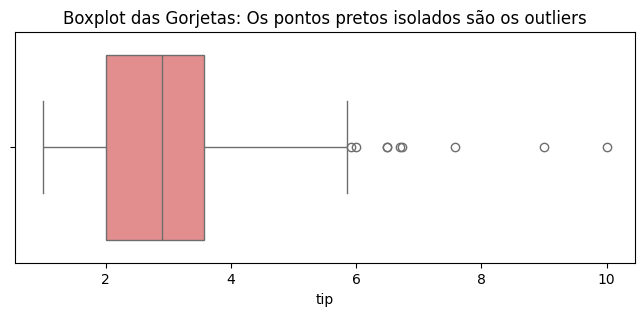

In [16]:
# Boxplot é a ferramenta estatística clássica para detectar outliers
plt.figure(figsize=(8, 3))
sns.boxplot(x=tips['tip'], color='lightcoral')
plt.title("Boxplot das Gorjetas: Os pontos pretos isolados são os outliers")
plt.show()

## 5. Conclusão e Próximos Passos

Neste notebook, compreendemos que os dados contam uma história antes mesmo de aplicarmos algoritmos complexos. Guarde os seguintes princípios para sua jornada:

1. Sem uma pergunta clara ("O contexto afeta a gorjeta?"), os gráficos são apenas imagens bonitas. A formulação do problema guia a exploração.
2. Padrões matemáticos são visíveis. A regressão linear nada mais é do que o algoritmo tentando reproduzir aquela reta central que você viu no Bloco 2.
3. Ao adicionar cores (categorias), descobrimos que uma regra universal ("maior conta = maior gorjeta") se divide em sub-regras (o caso dos fumantes). O modelo precisará de todas essas *features* para tomar decisões precisas.
4. Exceções comportamentais (outliers) confundem modelos matemáticos. Saber identificá-las visualmente é o primeiro passo para tratá-las.

### Próximos Passos

Conseguimos enxergar tendências visualmente, separar grupos por cores e identificar clientes fora do padrão. Nosso cérebro processa essas imagens com facilidade.

No entanto, se você tentar rodar o comando genérico `modelo.fit(X, y)` entregando a tabela `tips` do jeito que ela está, o Python retornará um erro fatal.

**Perguntas para análise:**
> **O computador não entende o texto "Lunch" ou a string "Yes" para fumantes. Como passaríamos a coluna 'dia da semana' para uma equação matemática $y = f(X)$?**

> **E se a conta estiver na escala das dezenas ($ 50) e o tamanho da mesa na escala das unidades (2 a 6 pessoas), o algoritmo não achará que a conta é matematicamente mais "importante" só por ter números maiores?**